In [7]:
import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output
import io
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load the data from local file as fallback (use if URL is broken)
df = pd.read_excel("2024_manhattan.xlsx", skiprows=3, engine='openpyxl')
df.columns = df.columns.str.strip().str.upper()

# Clean & convert columns
price_cols = ['AVERAGE SALE PRICE', 'MEDIAN SALE PRICE', 'MAXIMUM SALE PRICE', 'NUMBER OF SALES']
for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['NEIGHBORHOOD', 'AVERAGE SALE PRICE', 'NUMBER OF SALES'])
df['LIQUIDITY'] = df['AVERAGE SALE PRICE'] * df['NUMBER OF SALES']

# Encode categorical variables
df_encoded = pd.get_dummies(df[['NEIGHBORHOOD', 'AVERAGE SALE PRICE', 'MEDIAN SALE PRICE', 'MAXIMUM SALE PRICE', 'NUMBER OF SALES']], drop_first=True)
X = df_encoded.drop(columns=['AVERAGE SALE PRICE'])
y = df_encoded['AVERAGE SALE PRICE']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f"{name} MSE: {mse:.2f}")

# Dash app
app = Dash(__name__)
app.title = "NYC Real Estate Advisory 2024"

app.layout = html.Div([
    html.H1("NYC Manhattan 2024 Real Estate Market Dashboard", style={'textAlign': 'center'}),

    dcc.Dropdown(
        id='price_type',
        options=[
            {'label': 'Average Sale Price', 'value': 'AVERAGE SALE PRICE'},
            {'label': 'Median Sale Price', 'value': 'MEDIAN SALE PRICE'},
            {'label': 'Maximum Sale Price', 'value': 'MAXIMUM SALE PRICE'}
        ],
        value='AVERAGE SALE PRICE',
        style={'width': '60%', 'margin': 'auto'}
    ),

    html.Div([
        dcc.Graph(id='price_by_neighborhood'),
        dcc.Graph(id='sales_volume'),
        dcc.Graph(id='liquidity_plot'),
        dcc.Graph(id='affordable_growth')
    ])
])

@app.callback(
    [Output('price_by_neighborhood', 'figure'),
     Output('sales_volume', 'figure'),
     Output('liquidity_plot', 'figure'),
     Output('affordable_growth', 'figure')],
    [Input('price_type', 'value')]
)
def update_graphs(price_type):
    fig_price = px.bar(df, x='NEIGHBORHOOD', y=price_type,
                       title=f"{price_type} by Neighborhood",
                       labels={price_type: price_type}, height=400)

    fig_sales = px.bar(df, x='NEIGHBORHOOD', y='NUMBER OF SALES',
                       title="Number of Sales by Neighborhood", height=400)

    fig_liquidity = px.scatter(df, x='NUMBER OF SALES', y='AVERAGE SALE PRICE',
                               size='LIQUIDITY', color='NEIGHBORHOOD',
                               title="Liquidity: Sales Volume x Average Price")

    fig_affordable = px.scatter(df, x='MEDIAN SALE PRICE', y='NUMBER OF SALES',
                                color='NEIGHBORHOOD', size='NUMBER OF SALES',
                                title="Affordable Growth Potential: Sales vs. Median Price")

    return fig_price, fig_sales, fig_liquidity, fig_affordable

if __name__ == '__main__':
    app.run(debug=True, port=8060)


Random Forest MSE: 1073869320004.86
Linear Regression MSE: 3098707631204.65


Random Forest MSE: 1073869320004.86
Random Forest Predictions (first 5): [ 1311527.92916667  6961370.          6815200.24969697 10583007.97902205
 12275029.86488867]
Linear Regression MSE: 3098707631204.65
Linear Regression Predictions (first 5): [ 1007100.87835566  7135915.19270051  6778454.41515751  6001063.76092549
 10864592.3016079 ]


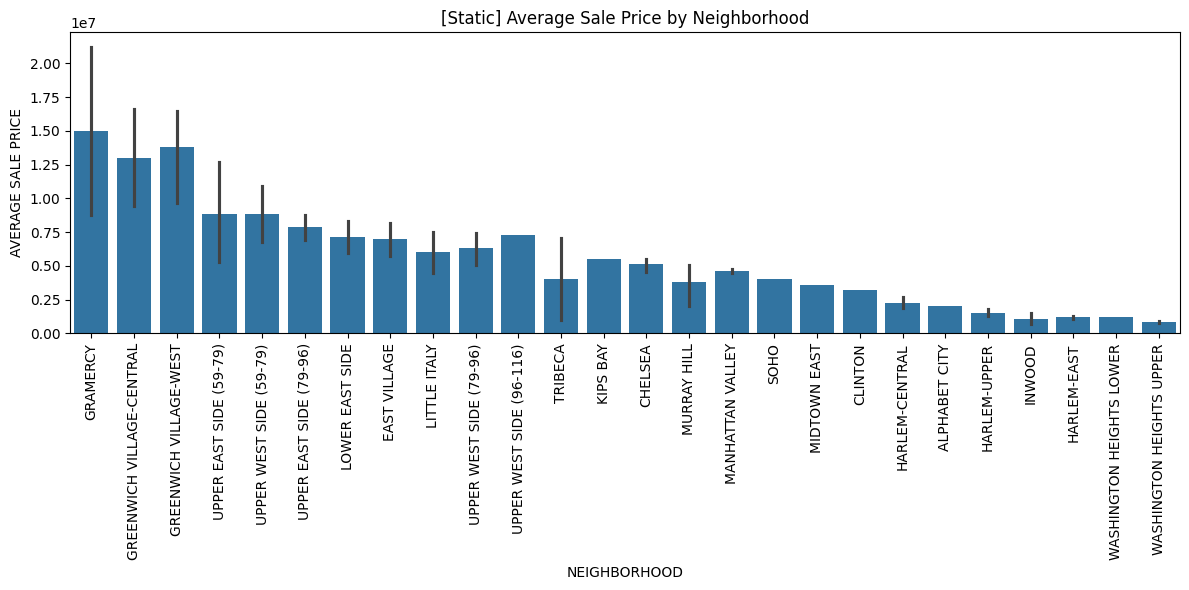

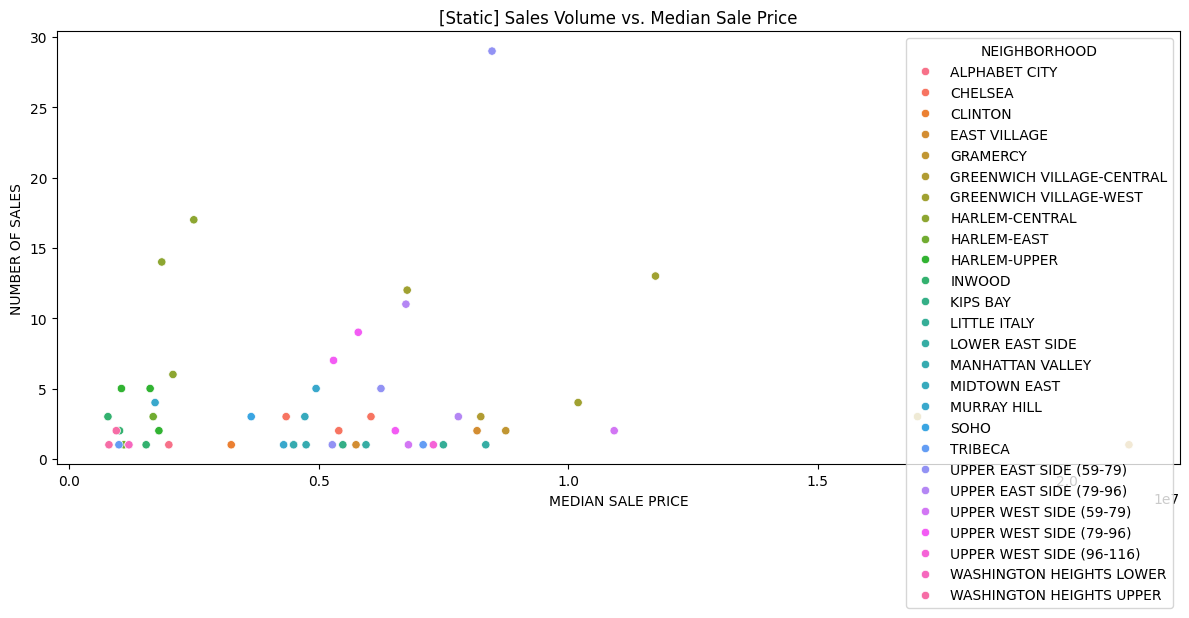

In [11]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from dash import Dash, dcc, html, Input, Output
import io
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load the data from local file as fallback (use if URL is broken)
df = pd.read_excel("2024_manhattan.xlsx", skiprows=3, engine='openpyxl')
df.columns = df.columns.str.strip().str.upper()

# Clean & convert columns
price_cols = ['AVERAGE SALE PRICE', 'MEDIAN SALE PRICE', 'MAXIMUM SALE PRICE', 'NUMBER OF SALES']
for col in price_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['NEIGHBORHOOD', 'AVERAGE SALE PRICE', 'NUMBER OF SALES'])
df['LIQUIDITY'] = df['AVERAGE SALE PRICE'] * df['NUMBER OF SALES']

# Encode categorical variables
df_encoded = pd.get_dummies(df[['NEIGHBORHOOD', 'AVERAGE SALE PRICE', 'MEDIAN SALE PRICE', 'MAXIMUM SALE PRICE', 'NUMBER OF SALES']], drop_first=True)
X = df_encoded.drop(columns=['AVERAGE SALE PRICE'])
y = df_encoded['AVERAGE SALE PRICE']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    print(f"{name} MSE: {mse:.2f}")
    print(f"{name} Predictions (first 5): {predictions[:5]}")

# Generate insights by neighborhood
def neighborhood_insight(neighborhood):
    sub = df[df['NEIGHBORHOOD'].str.contains(neighborhood, case=False)]
    if sub.empty:
        return "No data available for selected neighborhood."
    avg_price = sub['AVERAGE SALE PRICE'].mean()
    median_price = sub['MEDIAN SALE PRICE'].mean()
    max_price = sub['MAXIMUM SALE PRICE'].mean()
    volume = sub['NUMBER OF SALES'].sum()
    
    insights = [f"Selected neighborhood: {neighborhood.title()}\n"]
    if avg_price > 1_000_000 and volume > 10:
        insights.append("• High liquidity observed — suitable for low-risk, high-value development.")
    if avg_price > 1_200_000 and max_price > 2_000_000:
        insights.append("• Luxury repositioning potential — high average pricing without saturation.")
    if median_price < 800_000 and volume > 15:
        insights.append("• Affordable growth potential — trending upward in transaction volume.")
    return "\n".join(insights)

# Matplotlib/Seaborn visualizations for static reports
plt.figure(figsize=(12, 6))
sns.barplot(data=df.sort_values("AVERAGE SALE PRICE", ascending=False), x="NEIGHBORHOOD", y="AVERAGE SALE PRICE")
plt.xticks(rotation=90)
plt.title("[Static] Average Sale Price by Neighborhood")
plt.tight_layout()
plt.savefig("static_avg_price_by_neighborhood.png")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="MEDIAN SALE PRICE", y="NUMBER OF SALES", hue="NEIGHBORHOOD")
plt.title("[Static] Sales Volume vs. Median Sale Price")
plt.tight_layout()
plt.savefig("static_sales_vs_median_price.png")

# Dash app
app = Dash(__name__)
app.title = "NYC Real Estate Advisory 2024"

app.layout = html.Div([
    html.H1("NYC Manhattan 2024 Real Estate Market Dashboard", style={'textAlign': 'center'}),

    dcc.Dropdown(
        id='area_selector',
        options=[{'label': area, 'value': area} for area in sorted(df['NEIGHBORHOOD'].unique())],
        placeholder='Select a neighborhood to get insights',
        style={'width': '60%', 'margin': 'auto'}
    ),

    html.Div(id='neighborhood_insight', style={'padding': '20px', 'fontSize': '16px'}),

    dcc.Dropdown(
        id='price_type',
        options=[
            {'label': 'Average Sale Price', 'value': 'AVERAGE SALE PRICE'},
            {'label': 'Median Sale Price', 'value': 'MEDIAN SALE PRICE'},
            {'label': 'Maximum Sale Price', 'value': 'MAXIMUM SALE PRICE'}
        ],
        value='AVERAGE SALE PRICE',
        style={'width': '60%', 'margin': 'auto'}
    ),

    html.Div([
        dcc.Graph(id='price_by_neighborhood'),
        dcc.Graph(id='sales_volume'),
        dcc.Graph(id='liquidity_plot'),
        dcc.Graph(id='affordable_growth')
    ])
])

@app.callback(
    [Output('price_by_neighborhood', 'figure'),
     Output('sales_volume', 'figure'),
     Output('liquidity_plot', 'figure'),
     Output('affordable_growth', 'figure')],
    [Input('price_type', 'value')]
)
def update_graphs(price_type):
    fig_price = px.bar(df, x='NEIGHBORHOOD', y=price_type,
                       title=f"{price_type} by Neighborhood",
                       labels={price_type: price_type}, height=400)
    fig_price.write_html("output_price_by_neighborhood.html")

    fig_sales = px.bar(df, x='NEIGHBORHOOD', y='NUMBER OF SALES',
                       title="Number of Sales by Neighborhood", height=400)
    fig_sales.write_html("output_sales_volume.html")

    fig_liquidity = px.scatter(df, x='NUMBER OF SALES', y='AVERAGE SALE PRICE',
                               size='LIQUIDITY', color='NEIGHBORHOOD',
                               title="Liquidity: Sales Volume x Average Price")
    fig_liquidity.write_html("output_liquidity_plot.html")

    fig_affordable = px.scatter(df, x='MEDIAN SALE PRICE', y='NUMBER OF SALES',
                                color='NEIGHBORHOOD', size='NUMBER OF SALES',
                                title="Affordable Growth Potential: Sales vs. Median Price")
    fig_affordable.write_html("output_affordable_growth.html")

    return fig_price, fig_sales, fig_liquidity, fig_affordable

@app.callback(
    Output('neighborhood_insight', 'children'),
    Input('area_selector', 'value')
)
def update_insight(neighborhood):
    if neighborhood:
        return neighborhood_insight(neighborhood)
    return "Select a neighborhood to receive strategic insights."

if __name__ == '__main__':
    app.run(debug=True, port=8060)


In [12]:
# save this as app.py
from flask import Flask

app = Flask(__name__)

@app.route("/")
def hello():
    return "Hello, World!"